In [12]:
# Uncomment if needed:
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap fairlearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

import shap
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


In [11]:
!pip install imbalanced-learn fairlearn shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/251.6 kB ? eta -:--:--
   ------------------------------------- -- 235.5/251.6 kB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 251.6/251.6 kB 3.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/451.9 kB ? eta -:--:--
   ------------------------------------ -- 419.8/451.9 kB 13.2 MB/s eta 0:00:01
   ---------------------------------------- 451.9/451.9 kB 9.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   --------------------------------------- 235.4/235.4 kB 14.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv('data/healthcare-dataset-stroke-data.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns and types:')
print(df.dtypes)
df.head()

Dataset shape: (5110, 12)

Columns and types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
print('=== Missing values ===')
print(df.isnull().sum())
print(f'\nBMI has {df["bmi"].isnull().sum()} missing values — we will impute these.')

print(f'\n=== Class balance (stroke) ===')
print(df['stroke'].value_counts())
print(f'\nStroke prevalence: {df["stroke"].mean()*100:.1f}%')
print('The dataset is heavily imbalanced — only ~5% positive cases.')
print('We will use SMOTE to address this during training.')

=== Missing values ===
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

BMI has 201 missing values — we will impute these.

=== Class balance (stroke) ===
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke prevalence: 4.9%
The dataset is heavily imbalanced — only ~5% positive cases.
We will use SMOTE to address this during training.


In [6]:
print('=== Gender distribution ===')
print(df['gender'].value_counts())
print(f'\nThere is 1 row with gender="Other" — too few to analyse, we will drop it.')

print(f'\n=== Stroke rate by gender ===')
stroke_by_gender = df.groupby('gender')['stroke'].agg(['mean', 'sum', 'count'])
stroke_by_gender.columns = ['Stroke_Rate', 'Stroke_Count', 'Total']
print(stroke_by_gender)

=== Gender distribution ===
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

There is 1 row with gender="Other" — too few to analyse, we will drop it.

=== Stroke rate by gender ===
        Stroke_Rate  Stroke_Count  Total
gender                                  
Female     0.047094           141   2994
Male       0.051064           108   2115
Other      0.000000             0      1


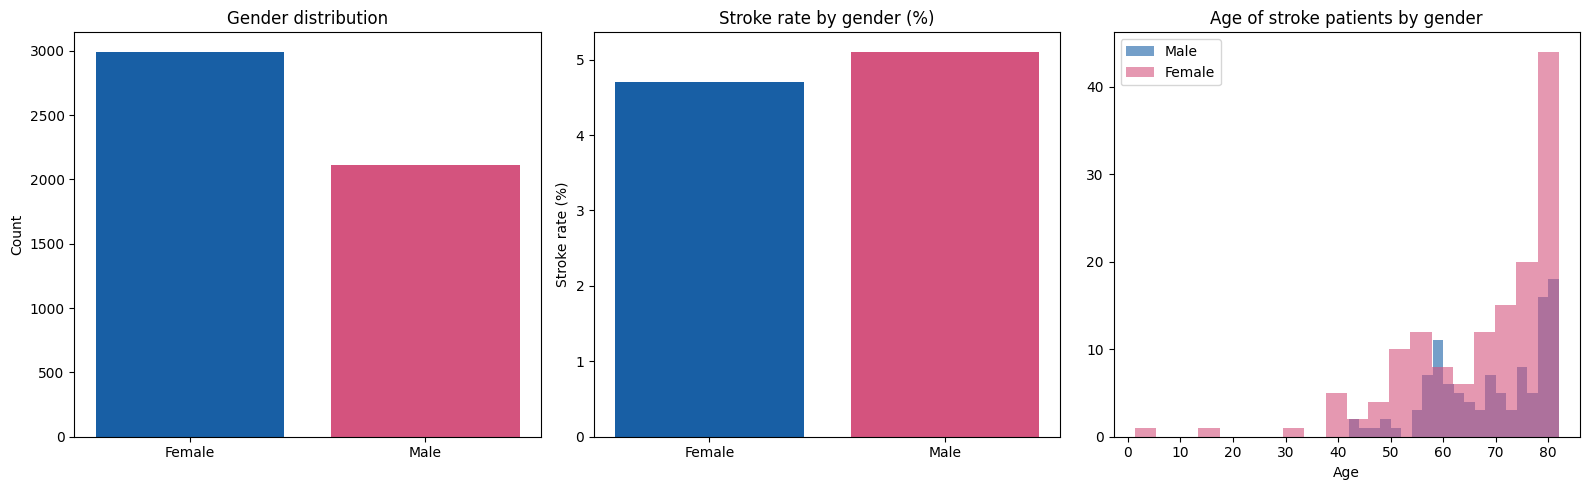

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender distribution
gender_counts = df[df['gender'] != 'Other']['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#185FA5', '#D4537E'])
axes[0].set_title('Gender distribution')
axes[0].set_ylabel('Count')

# Stroke rate by gender
stroke_rates = df[df['gender'] != 'Other'].groupby('gender')['stroke'].mean() * 100
axes[1].bar(stroke_rates.index, stroke_rates.values, color=['#185FA5', '#D4537E'])
axes[1].set_title('Stroke rate by gender (%)')
axes[1].set_ylabel('Stroke rate (%)')

# Age distribution of stroke cases
for gender, color in [('Male', '#185FA5'), ('Female', '#D4537E')]:
    subset = df[(df['gender'] == gender) & (df['stroke'] == 1)]
    axes[2].hist(subset['age'], alpha=0.6, bins=20, label=gender, color=color)
axes[2].set_title('Age of stroke patients by gender')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
data = df.copy()
data = data[data['gender'] != 'Other'].reset_index(drop=True)
data = data.drop('id', axis=1)

# Impute BMI grouped by gender and age bracket
data['age_bracket'] = pd.cut(data['age'], bins=[0, 18, 40, 60, 100],
                              labels=['child', 'young', 'middle', 'senior'])
data['bmi'] = data.groupby(['gender', 'age_bracket'])['bmi'].transform(
    lambda x: x.fillna(x.median())
)
data['bmi'] = data['bmi'].fillna(data['bmi'].median())
data = data.drop('age_bracket', axis=1)

# Save protected attribute BEFORE encoding
data['gender_binary'] = data['gender'].map({'Male': 1, 'Female': 0})

# Encode categoricals
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
work_type: {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
smoking_status: {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}


In [13]:
X = data.drop(['stroke', 'gender_binary'], axis=1)
y = data['stroke']
sensitive_feature = data['gender_binary']
feature_names = X.columns.tolist()

# Stratified split
X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_feature, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# SMOTE — training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}')

# Scale
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sm), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

Before SMOTE: {0: 3888, 1: 199}
After SMOTE:  {0: 3888, 1: 3888}


In [14]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
baseline_model.fit(X_train_scaled, y_train_sm)

y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

print('=== Baseline model — overall performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_baseline):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_baseline):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_baseline):.4f}')
print()
print(classification_report(y_test, y_pred_baseline, target_names=['No Stroke', 'Stroke']))

=== Baseline model — overall performance ===
Accuracy:  0.7681
Precision: 0.1390
Recall:    0.7200
F1 Score:  0.2330
AUC-ROC:   0.7809

              precision    recall  f1-score   support

   No Stroke       0.98      0.77      0.86       972
      Stroke       0.14      0.72      0.23        50

    accuracy                           0.77      1022
   macro avg       0.56      0.75      0.55      1022
weighted avg       0.94      0.77      0.83      1022



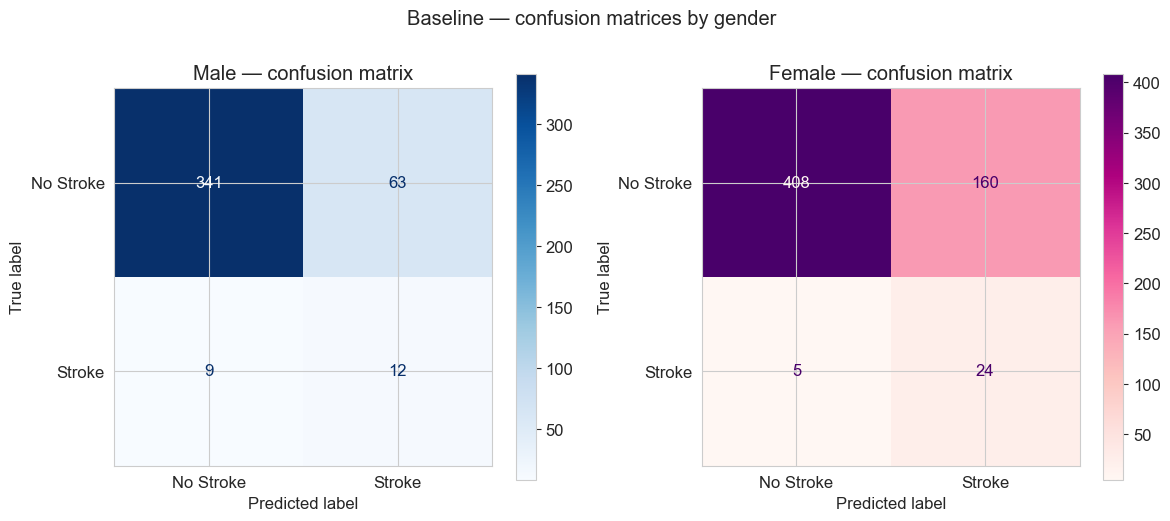

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (gval, gname, cmap) in zip(axes, [(1, 'Male', 'Blues'), (0, 'Female', 'RdPu')]):
    mask = sf_test == gval
    ConfusionMatrixDisplay.from_predictions(
        y_test[mask], y_pred_baseline[mask],
        display_labels=['No Stroke', 'Stroke'], cmap=cmap, ax=ax
    )
    ax.set_title(f'{gname} — confusion matrix')
plt.suptitle('Baseline — confusion matrices by gender', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
def compute_fairness_metrics(y_true, y_pred, sensitive, label='Model'):
    """Compute and display key fairness metrics."""
    metrics_dict = {
        'accuracy': accuracy_score,
        'precision': lambda yt, yp: precision_score(yt, yp, zero_division=0),
        'recall (TPR)': lambda yt, yp: recall_score(yt, yp, zero_division=0),
        'f1': lambda yt, yp: f1_score(yt, yp, zero_division=0),
        'selection_rate': lambda yt, yp: np.mean(yp),
    }
    
    mf = MetricFrame(metrics=metrics_dict, y_true=y_true, y_pred=y_pred,
                     sensitive_features=sensitive)
    
    print(f'\n{"="*65}')
    print(f'  FAIRNESS REPORT: {label}')
    print(f'{"="*65}')
    
    group_df = mf.by_group.copy()
    group_df.index = ['Female', 'Male']
    print(f'\nPer-group metrics:')
    print(group_df.round(4).to_string())
    
    dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)
    
    results = {}
    for gval, gname in [(0, 'Female'), (1, 'Male')]:
        mask = sensitive == gval
        yt, yp = y_true[mask], y_pred[mask]
        tp = int(((yp == 1) & (yt == 1)).sum())
        fn = int(((yp == 0) & (yt == 1)).sum())
        fp = int(((yp == 1) & (yt == 0)).sum())
        tn = int(((yp == 0) & (yt == 0)).sum())
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results[gname] = {'TPR': tpr, 'FPR': fpr, 'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn}
    
    tpr_diff = results['Male']['TPR'] - results['Female']['TPR']
    fpr_diff = results['Male']['FPR'] - results['Female']['FPR']
    
    print(f'\n--- Fairness differences (Male - Female) ---')
    print(f'  Demographic parity diff: {dp_diff:+.4f}  {"[FAIR]" if abs(dp_diff) <= 0.05 else "[UNFAIR]"}')
    print(f'  Equalized odds diff:     {eo_diff:+.4f}  {"[FAIR]" if abs(eo_diff) <= 0.05 else "[UNFAIR]"}')
    print(f'  TPR diff (M - F):        {tpr_diff:+.4f}  {"[FAIR]" if abs(tpr_diff) <= 0.05 else "[UNFAIR]"}')
    print(f'  FPR diff (M - F):        {fpr_diff:+.4f}  {"[FAIR]" if abs(fpr_diff) <= 0.05 else "[UNFAIR]"}')
    
    return {'dp_diff': dp_diff, 'eo_diff': eo_diff, 'tpr_diff': tpr_diff,
            'fpr_diff': fpr_diff, 'accuracy': accuracy_score(y_true, y_pred),
            'group_rates': results}

In [27]:
baseline_fairness = compute_fairness_metrics(
    y_test.values, y_pred_baseline, sf_test.values,
    label='Baseline logistic regression'
)


  FAIRNESS REPORT: Baseline logistic regression

Per-group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.7236     0.1304        0.8276  0.2254          0.3082
Male      0.8306     0.1600        0.5714  0.2500          0.1765

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.1317  [UNFAIR]
  Equalized odds diff:     +0.2562  [UNFAIR]
  TPR diff (M - F):        -0.2562  [UNFAIR]
  FPR diff (M - F):        -0.1257  [UNFAIR]


In [17]:
gender_corr = data[feature_names + ['gender_binary']].corr()['gender_binary'].drop('gender_binary')
print('=== Feature correlation with gender ===')
print(gender_corr.sort_values(key=abs, ascending=False).round(4))

proxy_features = gender_corr[gender_corr.abs() > 0.15].index.tolist()
print(f'\nProxy features (|r| > 0.15): {proxy_features}')
print('These will be removed in the pre-processing debiasing approach.')

=== Feature correlation with gender ===
gender               1.0000
heart_disease        0.0857
smoking_status      -0.0624
work_type            0.0566
avg_glucose_level    0.0547
ever_married        -0.0302
age                 -0.0278
bmi                 -0.0251
hypertension         0.0212
Residence_type      -0.0061
Name: gender_binary, dtype: float64

Proxy features (|r| > 0.15): ['gender']
These will be removed in the pre-processing debiasing approach.


In [18]:
features_to_remove = list(set(proxy_features + ['gender']))
keep_features = [f for f in feature_names if f not in features_to_remove]
print(f'Removing: {features_to_remove}')
print(f'Keeping ({len(keep_features)}): {keep_features}')

scaler_pre = StandardScaler()
X_train_pre = pd.DataFrame(scaler_pre.fit_transform(X_train_sm[keep_features]), columns=keep_features)
X_test_pre = pd.DataFrame(scaler_pre.transform(X_test[keep_features]),
                           columns=keep_features, index=X_test.index)

preproc_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
preproc_model.fit(X_train_pre, y_train_sm)
y_pred_preproc = preproc_model.predict(X_test_pre)

preproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_preproc, sf_test.values,
    label='Pre-processing (remove gender + proxies)'
)

Removing: ['gender']
Keeping (9): ['age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

  FAIRNESS REPORT: Pre-processing (remove gender + proxies)

Per-group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.7688     0.1484        0.7931  0.2500          0.2596
Male      0.7741     0.1359        0.6667  0.2258          0.2424

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.0173  [FAIR]
  Equalized odds diff:     +0.1264  [UNFAIR]
  TPR diff (M - F):        -0.1264  [UNFAIR]
  FPR diff (M - F):        -0.0121  [FAIR]


In [19]:
# Uses original (non-SMOTE) data — ExponentiatedGradient handles optimisation internally
scaler_in = StandardScaler()
X_train_in = pd.DataFrame(scaler_in.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_in = pd.DataFrame(scaler_in.transform(X_test), columns=feature_names, index=X_test.index)

inproc_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints=EqualizedOdds(), max_iter=50
)
inproc_model.fit(X_train_in, y_train, sensitive_features=sf_train)
y_pred_inproc = inproc_model.predict(X_test_in)

inproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_inproc, sf_test.values,
    label='In-processing (ExponentiatedGradient + EqualizedOdds)'
)


  FAIRNESS REPORT: In-processing (ExponentiatedGradient + EqualizedOdds)

Per-group metrics:
        accuracy  precision  recall (TPR)   f1  selection_rate
Female    0.9514        0.0           0.0  0.0             0.0
Male      0.9506        0.0           0.0  0.0             0.0

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.0000  [FAIR]
  Equalized odds diff:     +0.0000  [FAIR]
  TPR diff (M - F):        +0.0000  [FAIR]
  FPR diff (M - F):        +0.0000  [FAIR]


In [23]:
scaler_post = StandardScaler()
X_train_post = pd.DataFrame(scaler_post.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_post = pd.DataFrame(scaler_post.transform(X_test), columns=feature_names, index=X_test.index)

postproc_model = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints='equalized_odds', objective='accuracy_score', prefit=False
)
postproc_model.fit(X_train_post, y_train, sensitive_features=sf_train)
y_pred_postproc = postproc_model.predict(X_test_post, sensitive_features=sf_test)

postproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_postproc, sf_test.values,
    label='Post-processing (ThresholdOptimizer)'
)


  FAIRNESS REPORT: Post-processing (ThresholdOptimizer)

Per-group metrics:
        accuracy  precision  recall (TPR)   f1  selection_rate
Female    0.9514        0.0           0.0  0.0             0.0
Male      0.9506        0.0           0.0  0.0             0.0

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.0000  [FAIR]
  Equalized odds diff:     +0.0000  [FAIR]
  TPR diff (M - F):        +0.0000  [FAIR]
  FPR diff (M - F):        +0.0000  [FAIR]


=== FINAL COMPARISON ===
Fairness diffs closer to 0 = fairer. Threshold: |diff| <= 0.05

          Model  Accuracy  DP_Diff  EO_Diff  TPR_Diff  FPR_Diff
       Baseline    0.7681   0.1317   0.2562   -0.2562   -0.1257
 Pre-processing    0.7710   0.0173   0.1264   -0.1264   -0.0121
  In-processing    0.9511   0.0000   0.0000    0.0000    0.0000
Post-processing    0.9511   0.0000   0.0000    0.0000    0.0000


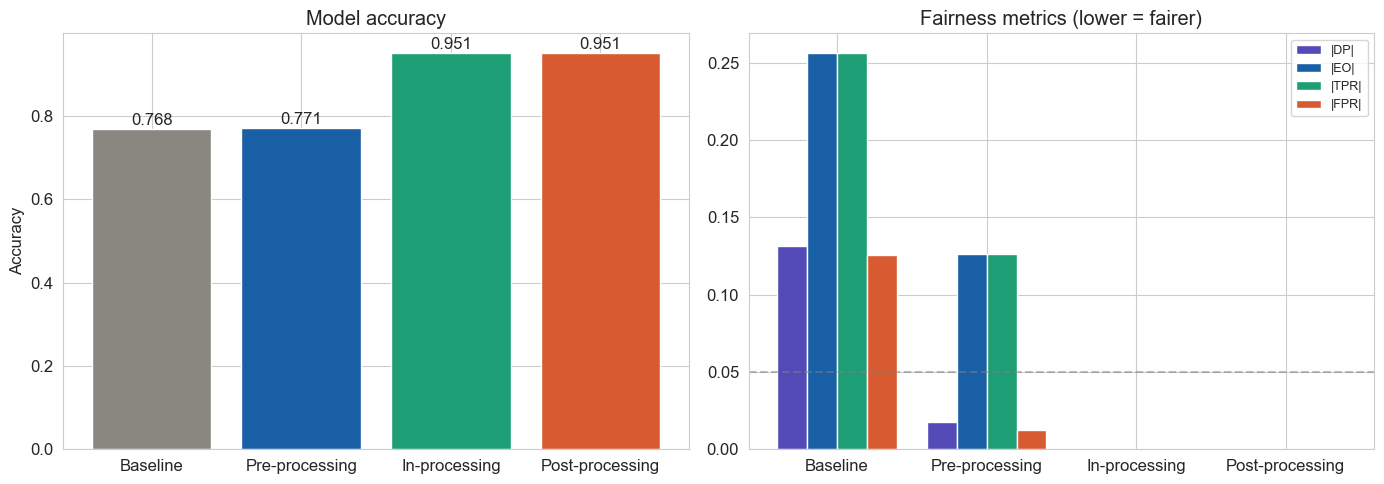

In [28]:
all_results = {
    'Baseline': baseline_fairness, 'Pre-processing': preproc_fairness,
    'In-processing': inproc_fairness, 'Post-processing': postproc_fairness
}

comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'Accuracy': [r['accuracy'] for r in all_results.values()],
    'DP_Diff': [r['dp_diff'] for r in all_results.values()],
    'EO_Diff': [r['eo_diff'] for r in all_results.values()],
    'TPR_Diff': [r['tpr_diff'] for r in all_results.values()],
    'FPR_Diff': [r['fpr_diff'] for r in all_results.values()],
})

print('=== FINAL COMPARISON ===')
print('Fairness diffs closer to 0 = fairer. Threshold: |diff| <= 0.05\n')
print(comparison_df.round(4).to_string(index=False))

# Accuracy vs fairness charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison_df['Model']
colors = ['#888780', '#185FA5', '#1D9E75', '#D85A30']

axes[0].bar(models, comparison_df['Accuracy'], color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model accuracy')
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

x = np.arange(len(models))
w = 0.2
axes[1].bar(x-1.5*w, comparison_df['DP_Diff'].abs(), w, label='|DP|', color='#534AB7')
axes[1].bar(x-0.5*w, comparison_df['EO_Diff'].abs(), w, label='|EO|', color='#185FA5')
axes[1].bar(x+0.5*w, comparison_df['TPR_Diff'].abs(), w, label='|TPR|', color='#1D9E75')
axes[1].bar(x+1.5*w, comparison_df['FPR_Diff'].abs(), w, label='|FPR|', color='#D85A30')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_title('Fairness metrics (lower = fairer)')
axes[1].legend(fontsize=9)
axes[1].axhline(y=0.05, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

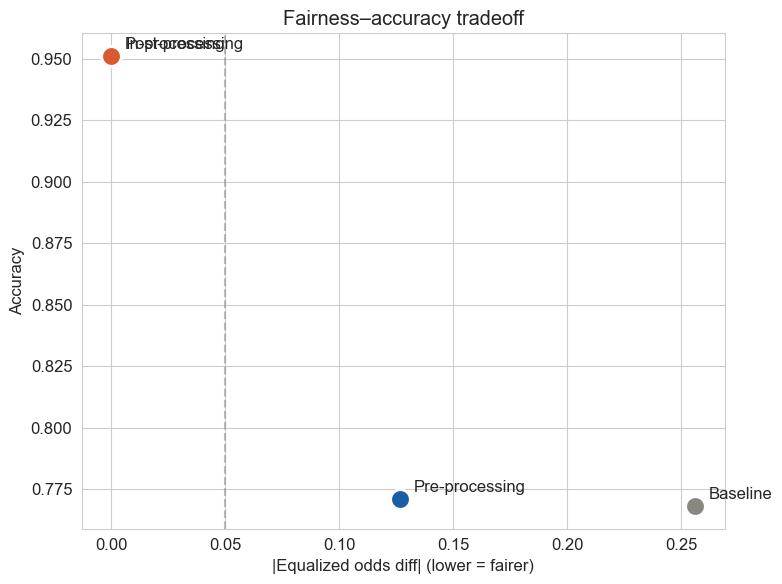

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, (model, acc, eo) in enumerate(
    zip(models, comparison_df['Accuracy'], comparison_df['EO_Diff'].abs())
):
    ax.scatter(eo, acc, s=200, c=colors[i], zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(model, (eo, acc), textcoords='offset points', xytext=(10, 5), fontsize=12)
ax.set_xlabel('|Equalized odds diff| (lower = fairer)')
ax.set_ylabel('Accuracy')
ax.set_title('Fairness–accuracy tradeoff')
ax.axvline(x=0.05, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [30]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)

print(f'\n1. DATASET: {len(data)} patients, {data["stroke"].mean()*100:.1f}% stroke rate')
print(f'\n2. BASELINE BIAS')
print(f'   EO diff: {baseline_fairness["eo_diff"]:+.4f}')
print(f'   Gender coefficient: {baseline_model.coef_[0][gender_idx]:+.4f}')
print(f'\n3. EXPLAINABILITY')
print(f'   Whitebox: coefficients directly readable')
print(f'   SHAP: confirmed differential importance by gender')
print(f'   Proxy features: {proxy_features}')
print(f'\n4. DEBIASING RESULTS')
print(comparison_df[['Model', 'Accuracy', 'EO_Diff']].round(4).to_string(index=False))

debiased = comparison_df.iloc[1:]
best = debiased.loc[debiased['EO_Diff'].abs().idxmin()]
print(f'\n   Best fairness: {best["Model"]} (EO: {best["EO_Diff"]:+.4f})')
print(f'   Accuracy cost: {comparison_df.iloc[0]["Accuracy"] - best["Accuracy"]:+.4f}')

SUMMARY

1. DATASET: 5109 patients, 4.9% stroke rate

2. BASELINE BIAS
   EO diff: +0.2562


NameError: name 'gender_idx' is not defined